In [11]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/STATS201_project/torres_replication/")
CAPSULE_DATA = DATA_DIR / "capsule" / "data"
IMAGES_DIR = CAPSULE_DATA / "Images2"

print("DATA_DIR exists:", DATA_DIR.exists())
print("CAPSULE_DATA exists:", CAPSULE_DATA.exists())
print("IMAGES_DIR exists:", IMAGES_DIR.exists())

meta_path = CAPSULE_DATA / "metadata_caravan_media_short.csv"
clusters_path = CAPSULE_DATA / "clusters_preds_caravan_newsapi.csv"

print("meta_path exists:", meta_path.exists())
print("clusters_path exists:", clusters_path.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIR exists: True
CAPSULE_DATA exists: True
IMAGES_DIR exists: True
meta_path exists: True
clusters_path exists: True


In [12]:
meta = pd.read_csv(meta_path, encoding="latin1")
clusters = pd.read_csv(clusters_path)

Drive link:
\
https://drive.google.com/drive/folders/14qz6L5HjYl0C8O5UKjrFLScukkT1Y4WT

In [13]:
import os

for f in os.listdir(DATA_DIR):
    print(f)


capsule
result
df_with_face_features.csv


In [15]:
df = meta

In [16]:
df.shape

(688, 15)

In [17]:
df.head()


,imageid,articleid,domain,screen_name2,newspapername,newspaperid,author,title,description,date,ideol_allsides,iscrowd,istrump,date2,topicality
0,abc-news_0000_11.jpg,abc-news_0000,abcnews.go.com,abc,ABC News,abc-news,b'ABC News',"b""WATCH: President Trump calls caravan migrant...",b'In an exclusive interview with ABC News Trum...,b'2018-11-01T17:05:40Z',left-center,0,1,11/1/18,0.000000
1,abc-news_0001_1.jpg,abc-news_0001,abcnews.go.com,abc,ABC News,abc-news,b'The Associated Press',"b'56,800 dead and missing: The hidden toll of ...","b""An Associated Press tally has documented mor...",b'2018-11-01T16:22:37Z',left-center,0,0,11/1/18,0.000000
2,abc-news_0002_1.jpg,abc-news_0002,abcnews.go.com,abc,ABC News,abc-news,b'The Associated Press',b'The Latest: Migrant caravan sets off toward ...,b'Thousands of Central American migrants have ...,b'2018-11-01T13:08:09Z',left-center,0,0,11/1/18,0.000000
3,abc-news_0003_2.jpg,abc-news_0003,abcnews.go.com,abc,ABC News,abc-news,b'Rick Klein and MaryAlice Parks',b'The Note: GOP closing with feuds and mixed m...,b'Trump is leading his party into a scattersho...,b'2018-11-01T10:01:15Z',left-center,0,1,11/1/18,0.626882
4,abc-news_0003_3.jpg,abc-news_0003,abcnews.go.com,abc,ABC News,abc-news,b'Rick Klein and MaryAlice Parks',b'The Note: GOP closing with feuds and mixed m...,b'Trump is leading his party into a scattersho...,b'2018-11-01T10:01:15Z',left-center,0,0,11/1/18,0.000000


In [18]:
df.tail()


,imageid,articleid,domain,screen_name2,newspapername,newspaperid,author,title,description,date,ideol_allsides,iscrowd,istrump,date2,topicality
683,vice-news_0017_5.jpg,vice-news_0017,news.vice.com,vicenews,Vice News,vice-news,"b'Dylan Baddour, VICE News'",b'Venezuelans desperate for work have resorted...,b'\xe2\x80\x9cIt\xe2\x80\x99s not just the bor...,b'2018-10-16T15:16:14Z',left,0,0,10/16/18,0.578055
684,vice-news_0017_6.jpg,vice-news_0017,news.vice.com,vicenews,Vice News,vice-news,"b'Dylan Baddour, VICE News'",b'Venezuelans desperate for work have resorted...,b'\xe2\x80\x9cIt\xe2\x80\x99s not just the bor...,b'2018-10-16T15:16:14Z',left,0,0,10/16/18,0.000000
685,wired_0000_3.jpg,wired_0000,www.wired.com,wired,Wired,wired,b'Adam Rogers',"b'Calling the Caravan\'s Migrants ""Diseased"" I...",b'The migrants almost certainly do not have sm...,b'2018-10-31T11:00:00Z',not-rated,1,0,10/31/18,0.969662
686,wired_0001_2.jpg,wired_0001,www.wired.com,wired,Wired,wired,b'Issie Lapowsky',b'Here\xe2\x80\x99s How Much Bots Drive Conver...,b'About 60 percent of Twitter activity related...,b'2018-10-30T18:00:00Z',not-rated,0,0,10/30/18,0.000000
687,wired_0002_5.jpg,wired_0002,www.wired.com,wired,Wired,wired,b'Emily Dreyfuss',"b""Don't Believe Everything You See About the M...",b'A migrant caravan traveling through Mexico i...,b'2018-10-24T00:16:57Z',not-rated,1,0,10/24/18,NaN


In [19]:
df.columns


Index(['imageid', 'articleid', 'domain', 'screen_name2', 'newspapername',
       'newspaperid', 'author', 'title', 'description', 'date',
       'ideol_allsides', 'iscrowd', 'istrump', 'date2', 'topicality'],
      dtype='object')

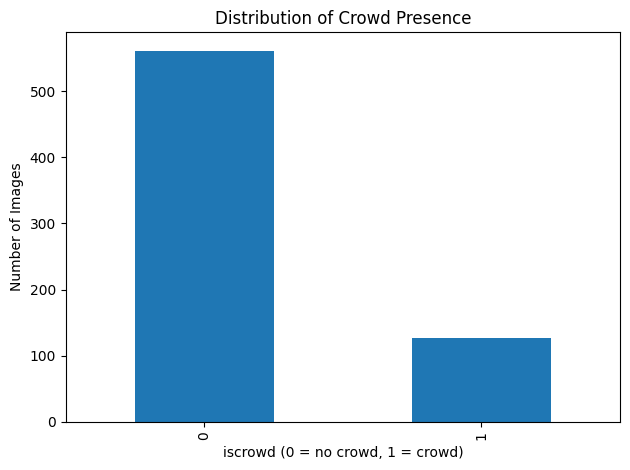

In [20]:
import matplotlib.pyplot as plt

df['iscrowd'].value_counts().plot(kind='bar')
plt.title("Distribution of Crowd Presence")
plt.xlabel("iscrowd (0 = no crowd, 1 = crowd)")
plt.ylabel("Number of Images")
plt.tight_layout()

# SAVE the figure
plt.savefig("label_distribution.png")
plt.show()

